# Overviews

The geotifs that hold the WaPOR data actually contain that data at multiple resolutions. So a single geotif has data for the same region
stored multiple times, but with different resolutions. Overview `-1` or `“NONE”` stores the original (most detailed) data. As the overview number
increases, the data becomes coarser. In the case of the WaPOR data, the resolution of each overview halfs, just like in the example
image below.

Using `gdal.Info` we can check if a geotif contains overviews.

In [1]:
from osgeo import gdal
gdal.UseExceptions()

url = "/vsicurl/https://storage.googleapis.com/fao-gismgr-wapor-3-data/DATA/WAPOR-3/MAPSET/L2-AETI-D/WAPOR-3.L2-AETI-D.2018-02-D3.tif"
info = gdal.Info(url, format = "json")

print(info["size"])
info["bands"][0]

[368640, 122880]


{'band': 1,
 'block': [512, 512],
 'type': 'Int16',
 'colorInterpretation': 'Gray',
 'noDataValue': -9999.0,
 'overviews': [{'size': [184320, 61440]},
  {'size': [92160, 30720]},
  {'size': [46080, 15360]},
  {'size': [23040, 7680]},
  {'size': [11520, 3840]},
  {'size': [5760, 1920]},
  {'size': [2880, 960]},
  {'size': [1440, 480]},
  {'size': [720, 240]},
  {'size': [360, 120]}],
 'offset': 0.0,
 'scale': 0.1,
 'metadata': {}}

So you can see that the original data has resolution `368640x122880`, then the first overview (`#0`) has a resolution of `184320x61440`, the second (`#1`) is `92160x30720`, etc.

When you want to determine timeseries for large areas and speed/bandwidth is an issue, it can save a lot of time and data-transfer to calculate the zonal statistics using a coarser resolution overview. 
Each pixel in an WaPOR overview is calculated from the 4 smaller pixels that cover the same area and gives the average of those 4 pixels.
Besides setting the overview you want to use manually, `WaPORDL` also allows you to set the overview to `"AUTO"`. In that case it will try to find a suitable overview for the shape for which you're downloading data. Notice that below we also set `make_plots=True` in order to output some plots that hopefully help you understand whats happening.

INFO: WaPORDL (`1.0.0`)
INFO: Found 1 files for L2-T-D.
INFO: Searching for optimal overview.
INFO: Using overview `1`.


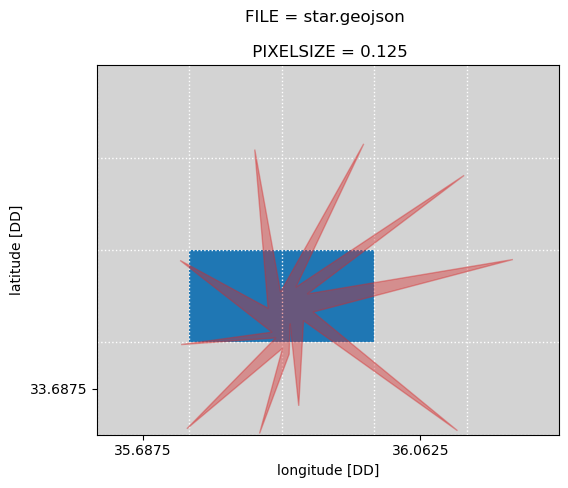

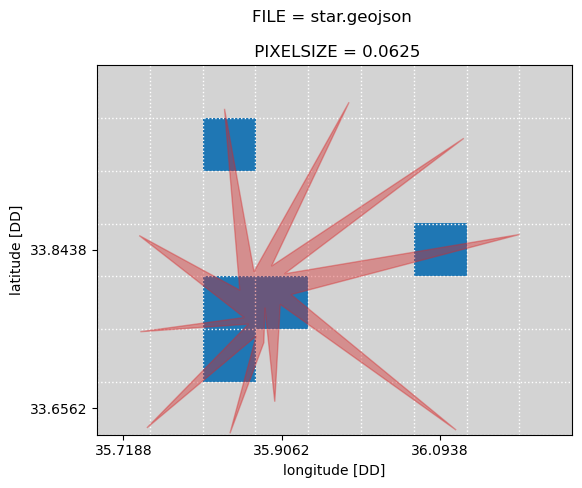

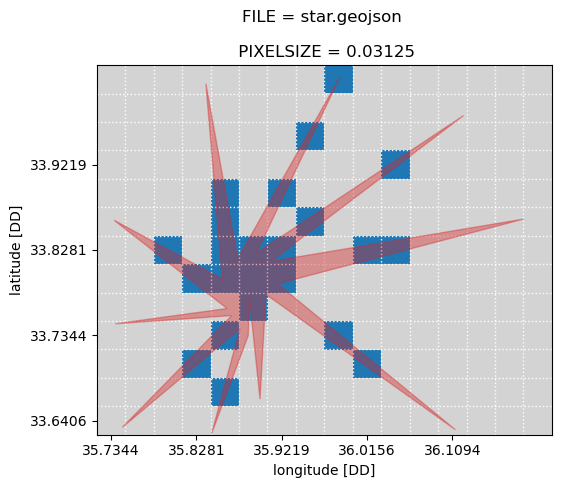

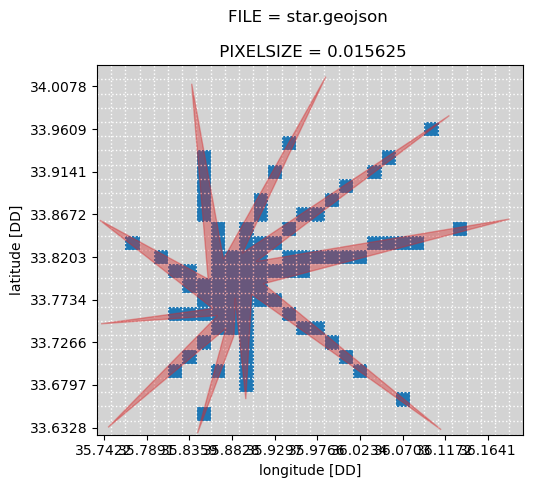

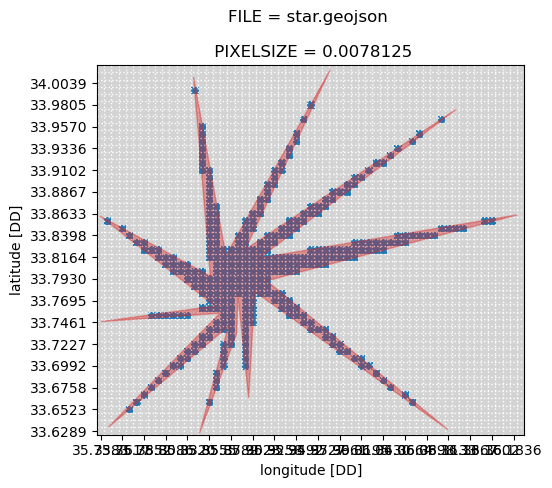

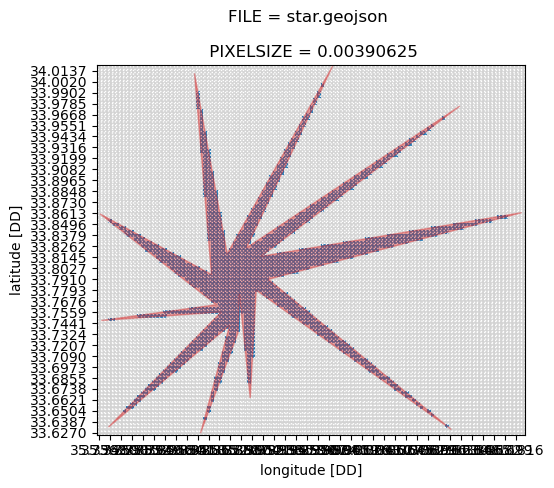

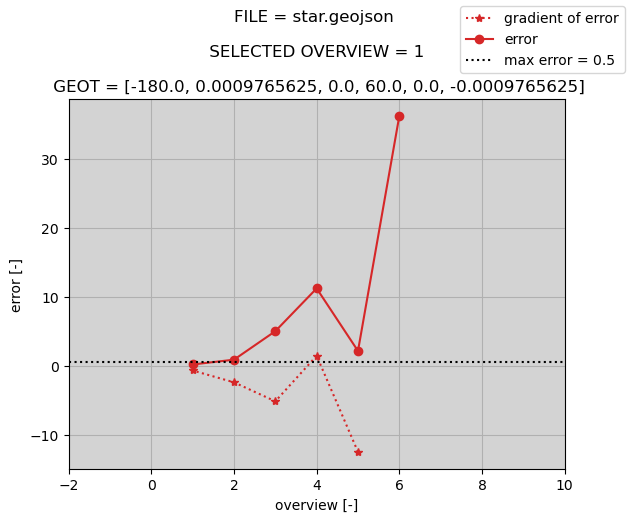

In [2]:
import wapordl

region = "../test_data/detector_shapes/star.geojson"
folder = "../archive"
variable = "L2-T-D"
period = ["2021-01-01", "2021-01-01"]

x = wapordl.wapor_map(
    region, 
    variable, 
    period, 
    folder, 
    overview="AUTO", 
    make_plots=True
)

The function we called above, evaluated for the different overviews available how well the pixels would be able to follow the given shape (a star shape in this case). a pixel-size of 0.00390625 (at overview #1) gives a error under the defined threshold and so the function proceeds with that overview. The error threshold can be adjusted by passing for example `max_error = 2.5` to the function.

Instead of a shape, we can also pass a bounding-box as our region of interest. In this case you can see that four pixels from overview `#7` align exactly with our area of interest.

INFO: Found 1 files for L2-T-D.
INFO: Searching for optimal overview.
INFO: Using overview `7`.


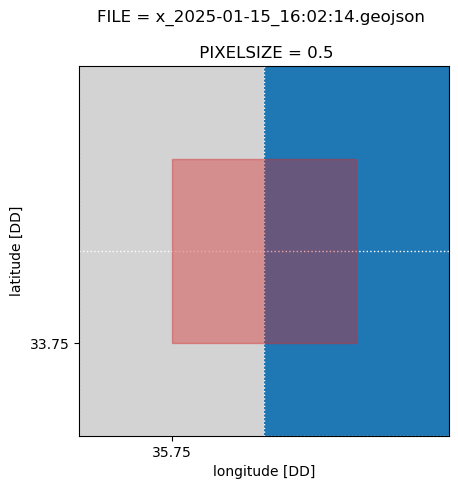

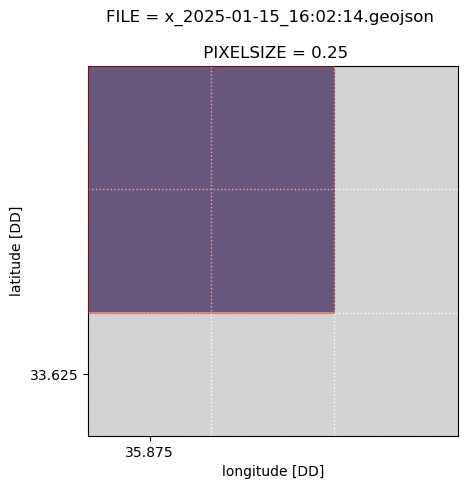

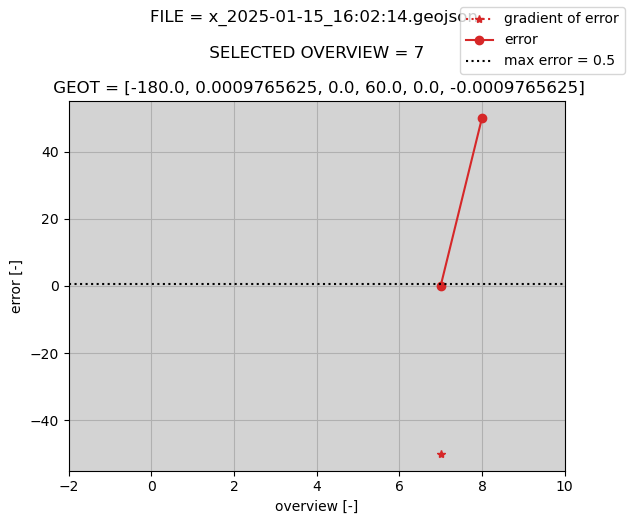

In [3]:
import wapordl

region = [35.75, 33.75, 36.25, 34.25]
folder = "../archive"
variable = "L2-T-D"
period = ["2021-01-01", "2021-01-01"]

x = wapordl.wapor_map(
    region, 
    variable, 
    period, 
    folder, 
    overview="AUTO", 
    make_plots=True
)